In [199]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [200]:
data = pd.read_csv('../artifacts/sentiment_analysis.csv')
data.head()

,id,label,tweet
0,1,0,#fingerprint #Pregnancy Test https://goo.gl/h1...
1,2,0,Finally a transparant silicon case ^^ Thanks t...
2,3,0,We love this! Would you go? #talk #makememorie...
3,4,0,I'm wired I know I'm George I was made that wa...
4,5,1,What amazing service! Apple won't even talk to...


## Data Preprocessing

In [201]:
## Data Preprocessing
data.shape

(7920, 3)

In [202]:
data.duplicated().sum()

np.int64(0)

In [203]:
data.isnull().sum()

id       0
label    0
tweet    0
dtype: int64

## Test Preprocessing

In [204]:
import re
import string

In [205]:
data["tweet"].head(6)

0    #fingerprint #Pregnancy Test https://goo.gl/h1...
1    Finally a transparant silicon case ^^ Thanks t...
2    We love this! Would you go? #talk #makememorie...
3    I'm wired I know I'm George I was made that wa...
4    What amazing service! Apple won't even talk to...
5    iPhone software update fucked up my phone big ...
Name: tweet, dtype: object

convert upercase to lowercase

In [206]:
data["tweet"] = data["tweet"].apply(lambda x: " ".join(x.lower() for x in x.split()) )

In [207]:
data["tweet"].head(6)

0    #fingerprint #pregnancy test https://goo.gl/h1...
1    finally a transparant silicon case ^^ thanks t...
2    we love this! would you go? #talk #makememorie...
3    i'm wired i know i'm george i was made that wa...
4    what amazing service! apple won't even talk to...
5    iphone software update fucked up my phone big ...
Name: tweet, dtype: object

Remove links

In [208]:
data["tweet"] = data["tweet"].apply(lambda x: " ".join(re.sub(r'^http:?:\/\/.*[\r\n]*', '', x, flags=re.MULTILINE) for x in x.split()) )

In [209]:
data["tweet"].head(6)

0    #fingerprint #pregnancy test https://goo.gl/h1...
1    finally a transparant silicon case ^^ thanks t...
2    we love this! would you go? #talk #makememorie...
3    i'm wired i know i'm george i was made that wa...
4    what amazing service! apple won't even talk to...
5    iphone software update fucked up my phone big ...
Name: tweet, dtype: object

In [210]:
data["tweet"].head(10)

0    #fingerprint #pregnancy test https://goo.gl/h1...
1    finally a transparant silicon case ^^ thanks t...
2    we love this! would you go? #talk #makememorie...
3    i'm wired i know i'm george i was made that wa...
4    what amazing service! apple won't even talk to...
5    iphone software update fucked up my phone big ...
6    happy for us .. #instapic #instadaily #us #son...
7    new type c charger cable #uk  … #bay #amazon #...
8    bout to go shopping again listening to music #...
9    photo: #fun #selfie #pool #water #sony #camera...
Name: tweet, dtype: object

Remove punctuation

In [211]:
def remove_punctuation(text):
    for punctuation in string.punctuation:
        text = text.replace(punctuation, "")
    return text

data["tweet"] = data["tweet"].apply(lambda x: " ".join(remove_punctuation(x) for x in x.split()) )

In [212]:
data["tweet"].head(10)

0    fingerprint pregnancy test httpsgooglh1mfqv an...
1    finally a transparant silicon case  thanks to ...
2    we love this would you go talk makememories un...
3    im wired i know im george i was made that way ...
4    what amazing service apple wont even talk to m...
5    iphone software update fucked up my phone big ...
6    happy for us  instapic instadaily us sony xper...
7    new type c charger cable uk … bay amazon etsy ...
8    bout to go shopping again listening to music i...
9    photo fun selfie pool water sony camera picoft...
Name: tweet, dtype: object

Remove numbers

In [213]:
data["tweet"].tail(10)

7910    perfect match instagood applewatch red instagr...
7911    i am completely in love with the new iphone em...
7912    tune in turn on drop out  gtd in one app mobil...
7913    ok so my galaxy crashed after one day now i ha...
7914    gain followers rt this must follow me i follow...
7915    live out loud lol liveoutloud selfie smile son...
7916    we would like to wish you an amazing day make ...
7917    helping my lovely 90 year old neighbor with he...
7918    finally got my smart pocket wifi stay connecte...
7919    apple barcelona apple store bcn barcelona trav...
Name: tweet, dtype: object

In [214]:
data["tweet"] = data["tweet"].str.replace(r'\d+', '', regex=True)

In [215]:
data["tweet"].tail(10)

7910    perfect match instagood applewatch red instagr...
7911    i am completely in love with the new iphone em...
7912    tune in turn on drop out  gtd in one app mobil...
7913    ok so my galaxy crashed after one day now i ha...
7914    gain followers rt this must follow me i follow...
7915    live out loud lol liveoutloud selfie smile son...
7916    we would like to wish you an amazing day make ...
7917    helping my lovely  year old neighbor with her ...
7918    finally got my smart pocket wifi stay connecte...
7919    apple barcelona apple store bcn barcelona trav...
Name: tweet, dtype: object

Remove stopwords

In [216]:
!pip install nltk

In [217]:
import nltk
nltk.download('stopwords',download_dir='../static/model')

[nltk_data] Downloading package stopwords to ../static/model...
[nltk_data]   Package stopwords is already up-to-date!


True

In [218]:
with open('../static/model/corpora/stopwords/english', 'r') as file:
    sw = file.read().splitlines()

In [219]:
sw

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [220]:
data["tweet"] = data["tweet"].apply(lambda x: " ".join(x for x in x.split() if x not in sw) )

In [221]:
data["tweet"].head(10)

0    fingerprint pregnancy test httpsgooglhmfqv and...
1    finally transparant silicon case thanks uncle ...
2    love would go talk makememories unplug relax i...
3    im wired know im george made way iphone cute d...
4    amazing service apple wont even talk question ...
5    iphone software update fucked phone big time s...
6    happy us instapic instadaily us sony xperia xp...
7    new type c charger cable uk … bay amazon etsy ...
8    bout go shopping listening music iphone justme...
9    photo fun selfie pool water sony camera picoft...
Name: tweet, dtype: object

In [222]:
data["tweet"].tail(10)

7910    perfect match instagood applewatch red instagr...
7911    completely love new iphone emojis iphone apple...
7912    tune turn drop gtd one app mobile mind meditat...
7913    ok galaxy crashed one day wait til monday skyr...
7914    gain followers rt must follow follow back foll...
7915    live loud lol liveoutloud selfie smile sony mu...
7916    would like wish amazing day make every minute ...
7917    helping lovely year old neighbor ipad morning ...
7918    finally got smart pocket wifi stay connected a...
7919    apple barcelona apple store bcn barcelona trav...
Name: tweet, dtype: object

stemming - get commen word

In [223]:
from nltk.stem import PorterStemmer
ps = PorterStemmer()
data["tweet"] = data["tweet"].apply(lambda x: " ".join(ps.stem(x) for x in x.split()) )


In [224]:
data["tweet"].tail(10)

7910    perfect match instagood applewatch red instagr...
7911         complet love new iphon emoji iphon appl emoj
7912    tune turn drop gtd one app mobil mind medit op...
7913    ok galaxi crash one day wait til monday skyroc...
7914    gain follow rt must follow follow back follow ...
7915    live loud lol liveoutloud selfi smile soni mus...
7916    would like wish amaz day make everi minut coun...
7917    help love year old neighbor ipad morn made rea...
7918    final got smart pocket wifi stay connect anyti...
7919    appl barcelona appl store bcn barcelona travel...
Name: tweet, dtype: object

## Building vocabulary

In [225]:
from collections import Counter
vocab = Counter()

In [226]:
vocab

Counter()

In [227]:
for sentence in data["tweet"]:
    vocab.update(sentence.split())

In [228]:
vocab.most_common(10)

[('iphon', 4073),
 ('appl', 2876),
 ('samsung', 1395),
 ('new', 1137),
 ('phone', 1015),
 ('follow', 885),
 ('soni', 819),
 ('…', 751),
 ('ipad', 537),
 ('rt', 525)]

In [229]:
len(vocab)

16872

In [230]:
data.shape

(7920, 3)

Get counter upto 15

In [231]:
token = [key for key in vocab if vocab[key] > 15]

In [232]:
len(token)

833

save token vocabulary

In [233]:
def save_vocabulary(line, filename):
    data = '\n'.join(line)
    file = open(filename, 'w', encoding='utf-8')
    file.write(data)
    file.close()

save_vocabulary(token, '../static/model/vocabulary.txt')

## Divide dataset

In [234]:
!pip install scikit-learn

In [235]:
x= data['tweet']
y= data['label']


In [236]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [237]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((6336,), (6336,), (1584,), (1584,))

## Vectorization - convert numerical values

In [238]:
def vectorizer(ds, vocabulary):
    vecorized_1st = []

    for sentence in ds: 
        sentence_1st = np.zeros(len(vocabulary))

        for i in range(len(vocabulary)):
            if vocabulary[i] in sentence.split():
                sentence_1st[i] = 1

        vecorized_1st.append(sentence_1st)

    vecorized_1st_new = np.array(vecorized_1st, dtype=np.float32)
    return vecorized_1st_new

In [239]:
vectorized_x_train = vectorizer(x_train, token)
vectorized_x_test = vectorizer(x_test, token)

In [240]:
vectorized_x_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(6336, 833), dtype=float32)

In [241]:
y_train

1551    1
2970    0
6646    0
2152    1
7850    0
       ..
7065    0
4295    0
1836    0
1568    0
7166    0
Name: label, Length: 6336, dtype: int64

In [242]:
vectorized_x_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1584, 833), dtype=float32)

In [243]:
y_test

3240    0
5352    0
1757    0
2499    1
937     0
       ..
2351    0
4129    1
5031    0
7442    0
6009    0
Name: label, Length: 1584, dtype: int64

chech balence

In [244]:
y_train.value_counts()

label
0    4738
1    1598
Name: count, dtype: int64

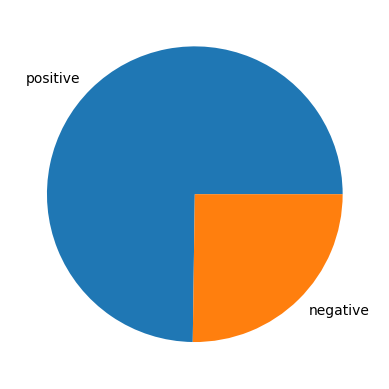

In [245]:
plt.pie(np.array([y_train.value_counts()[0], y_train.value_counts()[1]]), labels=['positive', 'negative'],)
plt.show()

Handel imbalence dataset

In [246]:
!pip install imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn

In [248]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
vectorized_x_train_smote, y_train_smote = smote.fit_resample(vectorized_x_train, y_train)
print(vectorized_x_train_smote.shape, y_train_smote.shape)

(9476, 833) (9476,)


In [249]:
y_train_smote.value_counts()

label
1    4738
0    4738
Name: count, dtype: int64

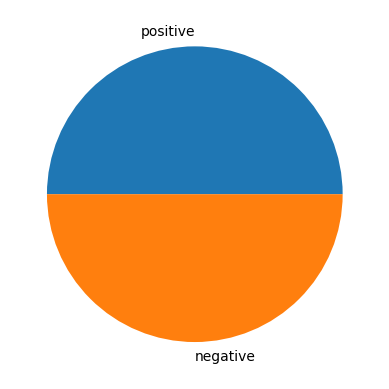

In [250]:
plt.pie(np.array([y_train_smote.value_counts()[0], y_train_smote.value_counts()[1]]), labels=['positive', 'negative'],)
plt.show()

In [251]:
vectorized_x_train_smote

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(9476, 833), dtype=float32)

In [252]:
y_train_smote

0       1
1       0
2       0
3       1
4       0
       ..
9471    1
9472    1
9473    1
9474    1
9475    1
Name: label, Length: 9476, dtype: int64

In [253]:
vectorized_x_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1584, 833), dtype=float32)

In [254]:
y_test

3240    0
5352    0
1757    0
2499    1
937     0
       ..
2351    0
4129    1
5031    0
7442    0
6009    0
Name: label, Length: 1584, dtype: int64

## Model training and evaluation

In [255]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [256]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def training_scores(y_act, y_pred):
    acc = round(accuracy_score(y_act, y_pred), 3)
    pre = round(precision_score(y_act, y_pred), 3)
    rec = round(recall_score(y_act, y_pred), 3)
    f1 = round(f1_score(y_act, y_pred), 3)
    print(f'Training scores:\n\tAccuracy = {acc}\n\tPrecision = {pre}\n\tRecall = {rec}\n\tF1 Score = {f1}')

def validation_scores(y_act, y_pred):
    acc = round(accuracy_score(y_act, y_pred), 3)
    pre = round(precision_score(y_act, y_pred), 3)
    rec = round(recall_score(y_act, y_pred), 3)
    f1 = round(f1_score(y_act, y_pred), 3)
    print(f'Training scores:\n\tAccuracy = {acc}\n\tPrecision = {pre}\n\tRecall = {rec}\n\tF1 Score = {f1}')

## Logistic Regression

In [264]:
lr = LogisticRegression()
lr.fit(vectorized_x_train_smote, y_train_smote)

y_traina_pred = lr.predict(vectorized_x_train_smote)

y_test_pred = lr.predict(vectorized_x_test)

training_scores(y_train_smote, y_traina_pred)

validation_scores(y_test, y_test_pred)

Training scores:
	Accuracy = 0.933
	Precision = 0.91
	Recall = 0.961
	F1 Score = 0.935
Training scores:
	Accuracy = 0.852
	Precision = 0.686
	Recall = 0.832
	F1 Score = 0.752


## Naive Bayes

In [269]:
mnb = MultinomialNB()
mnb.fit(vectorized_x_train_smote, y_train_smote)

y_traina_pred = mnb.predict(vectorized_x_train_smote)

y_test_pred = mnb.predict(vectorized_x_test)

training_scores(y_train_smote, y_traina_pred)

validation_scores(y_test, y_test_pred)

Training scores:
	Accuracy = 0.905
	Precision = 0.867
	Recall = 0.956
	F1 Score = 0.909
Training scores:
	Accuracy = 0.851
	Precision = 0.668
	Recall = 0.893
	F1 Score = 0.764


## Decision tree

In [274]:
dt = DecisionTreeClassifier()
dt.fit(vectorized_x_train_smote, y_train_smote)

y_traina_pred = dt.predict(vectorized_x_train_smote)

y_test_pred = dt.predict(vectorized_x_test)

training_scores(y_train_smote, y_traina_pred)

validation_scores(y_test, y_test_pred)

Training scores:
	Accuracy = 0.999
	Precision = 1.0
	Recall = 0.999
	F1 Score = 0.999
Training scores:
	Accuracy = 0.821
	Precision = 0.676
	Recall = 0.65
	F1 Score = 0.663


## Ramdom Forest

In [279]:
rf = RandomForestClassifier()
rf.fit(vectorized_x_train_smote, y_train_smote)

y_traina_pred = rf.predict(vectorized_x_train_smote)

y_test_pred = rf.predict(vectorized_x_test)

training_scores(y_train_smote, y_traina_pred)

validation_scores(y_test, y_test_pred)

Training scores:
	Accuracy = 0.999
	Precision = 1.0
	Recall = 0.999
	F1 Score = 0.999
Training scores:
	Accuracy = 0.85
	Precision = 0.725
	Recall = 0.715
	F1 Score = 0.72


## Suppoted vector machine

In [284]:
svm = SVC()
svm.fit(vectorized_x_train_smote, y_train_smote)

y_traina_pred = svm.predict(vectorized_x_train_smote)

y_test_pred = svm.predict(vectorized_x_test)

training_scores(y_train_smote, y_traina_pred)

validation_scores(y_test, y_test_pred)

Training scores:
	Accuracy = 0.974
	Precision = 0.956
	Recall = 0.993
	F1 Score = 0.974
Training scores:
	Accuracy = 0.851
	Precision = 0.7
	Recall = 0.785
	F1 Score = 0.74


In [289]:
import pickle
with open('../static/model/logistic_regression_model.pkl', 'wb') as file:
    pickle.dump(lr, file)

In [294]:
import pickle
with open('../static/model/supported_vector_machine.pkl', 'wb') as file:
    pickle.dump(svm, file)